In [1]:
import pandas as pd

df = pd.read_csv('./employee_data.csv')
print(df.head())

df = df.drop(columns=['EmployeeNumber'])

   Age Attrition  ... YearsSinceLastPromotion  YearsWithCurrManager
0   34        No  ...                       1                     3
1   38        No  ...                       1                     0
2   51        No  ...                       0                     0
3   60        No  ...                       2                     2
4   23        No  ...                       1                     4

[5 rows x 35 columns]


In [2]:
print(df.head()['StandardHours'].nunique())
print(df.head()['Over18'].nunique())
print(df.head()['EmployeeCount'].nunique())

df = df.drop(columns=['StandardHours', 'Over18', 'EmployeeCount'])

1
1
1


In [3]:
df.isna().sum().sort_values(ascending=False)

Age                         0
MonthlyIncome               0
YearsSinceLastPromotion     0
YearsInCurrentRole          0
YearsAtCompany              0
WorkLifeBalance             0
TrainingTimesLastYear       0
TotalWorkingYears           0
StockOptionLevel            0
RelationshipSatisfaction    0
PerformanceRating           0
PercentSalaryHike           0
OverTime                    0
NumCompaniesWorked          0
MonthlyRate                 0
MaritalStatus               0
Attrition                   0
JobSatisfaction             0
JobRole                     0
JobLevel                    0
JobInvolvement              0
HourlyRate                  0
Gender                      0
EnvironmentSatisfaction     0
EducationField              0
Education                   0
DistanceFromHome            0
Department                  0
DailyRate                   0
BusinessTravel              0
YearsWithCurrManager        0
dtype: int64

In [4]:
from sklearn.preprocessing import OneHotEncoder

columns_to_encode = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'Attrition', 'JobRole', 'MaritalStatus', 'OverTime']
ohe = OneHotEncoder(sparse_output=False)
encoded_data = ohe.fit_transform(df[columns_to_encode])
encoded_df = pd.DataFrame(encoded_data, columns=ohe.get_feature_names_out(columns_to_encode))
df = pd.concat([df.drop(columns=columns_to_encode), encoded_df], axis=1)
print(df.columns)

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'BusinessTravel_Non-Travel', 'BusinessTravel_Travel_Frequently',
       'BusinessTravel_Travel_Rarely', 'Department_Human Resources',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Human Resources', 'EducationField_Life Sciences',
       'EducationField_Marketing', 'EducationField_Medical',
       'EducationField_Other', 'EducationField_Technical Degree',
       'Gender_Female', 'Gender_Male', 'Attrition_No', 'Attrition_Yes',
       'JobRole_Healthcare Repr

In [5]:
df.corrwith(df['MonthlyIncome']).sort_values(ascending=False)

MonthlyIncome                        1.000000
JobLevel                             0.947914
TotalWorkingYears                    0.771027
JobRole_Manager                      0.618505
YearsAtCompany                       0.513625
Age                                  0.506209
JobRole_Research Director            0.473482
YearsInCurrentRole                   0.356812
YearsSinceLastPromotion              0.340469
YearsWithCurrManager                 0.339835
Attrition_No                         0.156702
NumCompaniesWorked                   0.140602
Education                            0.088127
JobRole_Healthcare Representative    0.077132
Department_Sales                     0.071252
EducationField_Marketing             0.062355
JobRole_Manufacturing Director       0.055605
JobRole_Sales Executive              0.054119
MaritalStatus_Married                0.052193
MonthlyRate                          0.039362
Gender_Female                        0.036490
OverTime_Yes                      

In [6]:
df['age_x_experience'] = df['Age'] * df['YearsAtCompany']
df['age_group'] = df['Age'] // 10

df.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Female,Gender_Male,Attrition_No,Attrition_Yes,JobRole_Healthcare Representative,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,OverTime_No,OverTime_Yes,age_x_experience,age_group
0,34,702,16,4,3,100,2,1,4,2553,8306,1,16,3,3,0,6,3,3,5,2,1,3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,170,3
1,38,833,18,3,2,60,1,2,4,5811,24539,3,16,3,3,1,15,2,3,1,0,1,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,38,3
2,51,833,1,3,3,96,3,1,4,2723,23231,1,11,3,2,0,1,0,2,1,0,0,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,51,5
3,60,1179,16,4,1,84,3,2,1,5405,11924,8,14,3,4,0,10,1,3,2,2,2,2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,120,6
4,23,571,12,2,4,78,3,1,4,2647,13672,1,13,3,3,0,5,6,4,5,2,1,4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,115,2


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
columns_to_scale = df.columns.drop('MonthlyIncome')
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

df.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Female,Gender_Male,Attrition_No,Attrition_Yes,JobRole_Healthcare Representative,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,OverTime_No,OverTime_Yes,age_x_experience,age_group
0,-0.330281,-0.251453,0.829303,1.071617,0.255874,1.688102,-1.04365,-0.971272,1.158187,2553,-0.835438,-0.673999,0.206609,-0.432738,0.247304,-0.925834,-0.679798,0.175187,0.339114,-0.331897,-0.618489,-0.366764,-0.327034,-0.342306,2.055709,-1.541323,-0.21051,0.731025,-0.663777,-0.139971,1.195810,-0.35673,-0.667534,-0.236200,-0.324515,1.223928,-1.223928,0.437943,-0.437943,-0.319974,-0.191088,-0.470020,-0.271931,-0.329017,-0.234305,2.055709,-0.540022,-0.241815,-0.533835,-0.920670,1.459564,0.627673,-0.627673,-0.367123,-0.26085
1,0.105557,0.073702,1.075922,0.092502,-0.659848,-0.275520,-2.46206,-0.056401,1.158187,5811,1.424935,0.134282,0.206609,-0.432738,0.247304,0.254132,0.469489,-0.609074,0.339114,-0.979869,-1.173043,-0.366764,-1.160072,-0.342306,-0.486450,0.648793,-0.21051,0.731025,-0.663777,-0.139971,-0.836253,-0.35673,1.498051,-0.236200,-0.324515,-0.817041,0.817041,0.437943,-0.437943,3.125259,-0.191088,-0.470020,-0.271931,-0.329017,-0.234305,-0.486450,-0.540022,-0.241815,-0.533835,1.086166,-0.685136,-1.593187,1.593187,-0.811836,-0.26085
2,1.522032,0.073702,-1.020339,0.092502,0.255874,1.491740,0.37476,-0.971272,1.158187,2723,1.242802,-0.673999,-1.150145,-0.432738,-0.674733,-0.925834,-1.318290,-2.177596,-1.063382,-0.979869,-1.173043,-0.671750,-1.160072,-0.342306,-0.486450,0.648793,-0.21051,0.731025,-0.663777,-0.139971,1.195810,-0.35673,-0.667534,-0.236200,-0.324515,-0.817041,0.817041,0.437943,-0.437943,-0.319974,-0.191088,-0.470020,-0.271931,-0.329017,-0.234305,2.055709,-0.540022,-0.241815,-0.533835,1.086166,-0.685136,0.627673,-0.627673,-0.768039,1.80773
3,2.502669,0.932507,0.829303,1.071617,-1.575570,0.902653,0.37476,-0.056401,-1.542328,5405,-0.331648,2.154985,-0.336093,-0.432738,1.169341,-0.925834,-0.169004,-1.393335,0.339114,-0.817876,-0.618489,-0.061779,-0.604714,-0.342306,-0.486450,0.648793,-0.21051,-1.367942,1.506530,-0.139971,-0.836253,2.80324,-0.667534,-0.236200,-0.324515,-0.817041,0.817041,0.437943,-0.437943,-0.319974,-0.191088,-0.470020,-0.271931,-0.329017,-0.234305,-0.486450,1.851777,-0.241815,-0.533835,-0.920670,1.459564,0.627673,-0.627673,-0.535575,2.84202
4,-1.528837,-0.576607,0.336065,-0.886613,1.171596,0.608110,0.37476,-0.971272,1.158187,2647,-0.088247,-0.673999,-0.607444,-0.432738,0.247304,-0.925834,-0.807496,2.527971,1.741611,-0.331897,-0.618489,-0.366764,-0.049355,-0.342306,-0.486450,0.648793,-0.21051,0.731025,-0.663777,-0.139971,-0.836253,-0.35673,-0.667534,4.233703,-0.324515,-0.817041,0.817041,0.437943,-0.437943,-0.319974,-0.191088,2.127569,-0.271931,-0.329017,-0.234305,-0.486450,-0.540022,-0.241815,-0.533835,-0.920670,1.459564,0.627673,-0.627673,-0.552420,-1.29514


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV

X = df.drop(columns=['MonthlyIncome'])
y = df['MonthlyIncome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def train_linear():
    linear_model = LinearRegression()
    linear_model.fit(X_train, y_train)
    return linear_model

def train_xgboost():
    xgb_model = XGBRegressor(random_state=42, max_depth=5)
    xgb_model.fit(X_train, y_train)
    return xgb_model

def train_logistic():
    logistic_model = LogisticRegression(random_state=42, max_iter=1000)
    logistic_model.fit(X_train, y_train)
    return logistic_model

def train_rf():
    rf_model = RandomForestRegressor(random_state=42)
    rf_model.fit(X_train, y_train)
    return rf_model

def train_xgboost_hyperparamterized():
    xgb = XGBRegressor(random_state=42)

    param_dist = {
        "n_estimators": [100, 300, 500, 800],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "max_depth": [3, 5, 7, 10],
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0]
    }

    random_search = RandomizedSearchCV(
        xgb,
        param_distributions=param_dist,
        n_iter=20,
        scoring="neg_root_mean_squared_error",
        cv=3,
        verbose=1,
        n_jobs=-1
    )
    random_search.fit(X_train, y_train)
    return random_search.best_estimator_

def train_rf_hyperparamterized():
    rf = RandomForestRegressor(random_state=42)

    param_dist = {
        "n_estimators": [100, 300, 500, 800],
        "max_depth": [3, 5, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "bootstrap": [True, False]
    }

    random_search = RandomizedSearchCV(
        rf,
        param_distributions=param_dist,
        n_iter=20,
        scoring="neg_root_mean_squared_error",
        cv=3,
        verbose=1,
        n_jobs=-1
    )
    random_search.fit(X_train, y_train)
    return random_search.best_estimator_

linear_model = train_linear()
logistic_model = train_logistic()
rf_model = train_rf()
rf_hyper_model = train_rf_hyperparamterized()
xgb_model = train_xgboost()
xgb_hyper_model = train_xgboost_hyperparamterized()

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Fitting 3 folds for each of 20 candidates, totalling 60 fits


In [9]:
def test_linear():
    y_pred = linear_model.predict(X_test)
    linear_rmse = root_mean_squared_error(y_test, y_pred)
    linear_r2 = r2_score(y_test, y_pred)

    print(f'Linear RMSE: {linear_rmse}')
    print(f'Linear R²: {linear_r2}')

    plt.scatter(y_test, y_pred)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.plot([min_val, max_val], [min_val, max_val])
    plt.show()

def test_logistic():
    y_pred = logistic_model.predict(X_test)
    logistic_rmse = root_mean_squared_error(y_test, y_pred)
    logistic_r2 = r2_score(y_test, y_pred)

    print(f'Logistic RMSE: {logistic_rmse}')
    print(f'Logistic R²: {logistic_r2}')

    plt.scatter(y_test, y_pred)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.plot([min_val, max_val], [min_val, max_val])
    plt.show()

def test_rf():
    y_pred = rf_model.predict(X_test)
    rf_rmse = root_mean_squared_error(y_test, y_pred)
    rf_r2 = r2_score(y_test, y_pred)

    print(f'Random Forest RMSE: {rf_rmse}')
    print(f'Random Forest R²: {rf_r2}')

    plt.scatter(y_test, y_pred)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.plot([min_val, max_val], [min_val, max_val])
    plt.show()

def test_xgboost():
    y_pred = xgb_model.predict(X_test)
    xgb_rmse = root_mean_squared_error(y_test, y_pred)
    xgb_r2 = r2_score(y_test, y_pred)

    print(f'XGBoost RMSE: {xgb_rmse}')
    print(f'XGBoost R²: {xgb_r2}')

    plt.scatter(y_test, y_pred)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.plot([min_val, max_val], [min_val, max_val])
    plt.show()

def test_xgboost_hyperparamterized():
    y_pred = xgb_hyper_model.predict(X_test)
    best_rmse = root_mean_squared_error(y_test, y_pred)
    best_r2 = r2_score(y_test, y_pred)
    print(f'Best XGBoost RMSE: {best_rmse}')
    print(f'Best XGBoost R²: {best_r2}')

    plt.scatter(y_test, y_pred)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.plot([min_val, max_val], [min_val, max_val])
    plt.show()

def test_rf_hyperparamterized():
    y_pred = rf_hyper_model.predict(X_test)
    best_rmse = root_mean_squared_error(y_test, y_pred)
    best_r2 = r2_score(y_test, y_pred)
    print(f'Best Random Forest RMSE: {best_rmse}')
    print(f'Best Random Forest R²: {best_r2}')

    plt.scatter(y_test, y_pred)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.plot([min_val, max_val], [min_val, max_val])
    plt.show()

Linear RMSE: 1088.2100350375317
Linear R²: 0.9441808768811403


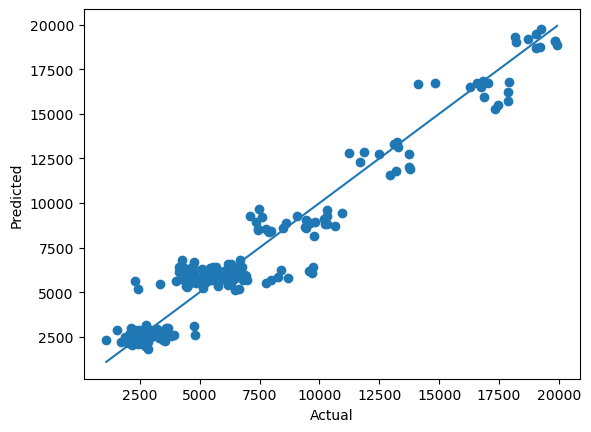

Logistic RMSE: 2871.301883815075
Logistic R²: 0.6113888398399832


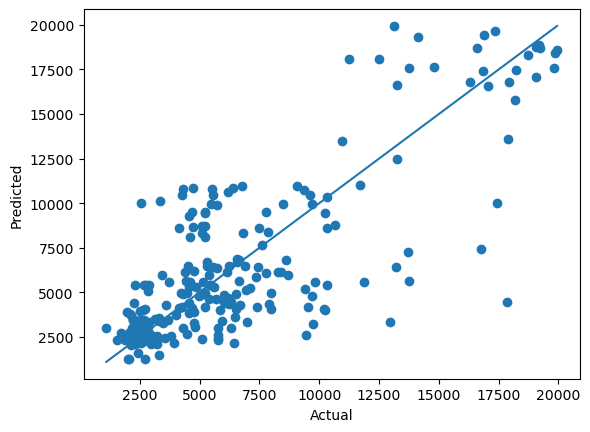

Random Forest RMSE: 1024.4065021328204
Random Forest R²: 0.9505345220735049


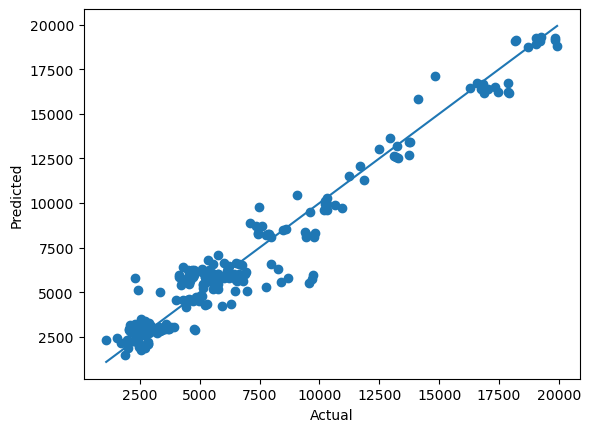

Best Random Forest RMSE: 999.3657307596284
Best Random Forest R²: 0.9529232511320319


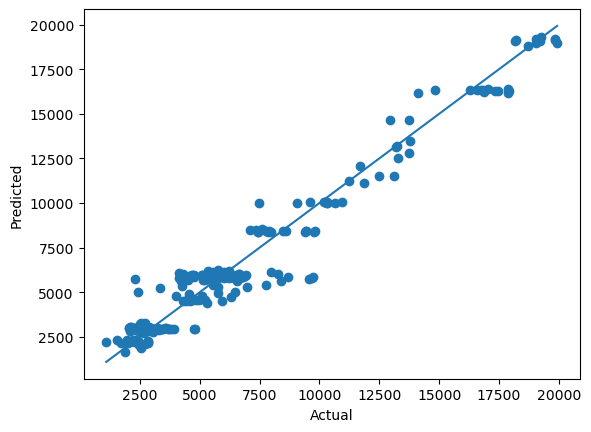

XGBoost RMSE: 1130.7694091796875
XGBoost R²: 0.9397293925285339


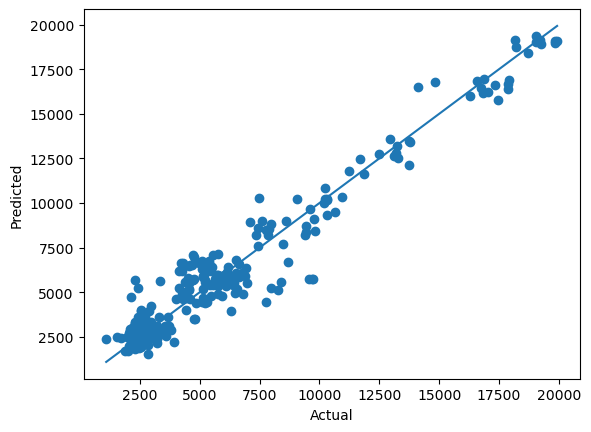

Best XGBoost RMSE: 1002.053466796875
Best XGBoost R²: 0.9526696801185608


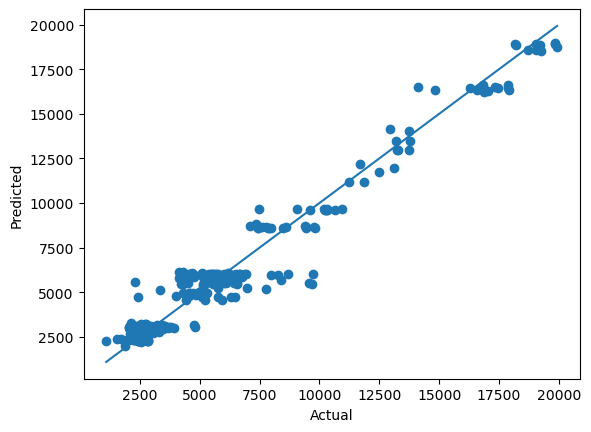

In [10]:
test_linear()
test_logistic()
test_rf()
test_rf_hyperparamterized()
test_xgboost()
test_xgboost_hyperparamterized()

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
import numpy as np

df = pd.read_csv('./employee_data.csv')

drop_columns = ['EmployeeNumber', 'StandardHours', 'Over18', 'EmployeeCount']

preprocessor = ColumnTransformer(
    transformers=[
        ('drop', 'drop', drop_columns),
        ('cat', OneHotEncoder(sparse_output=False), columns_to_encode),
        ('num', StandardScaler(), make_column_selector(dtype_include=np.number)),
    ]
)

operacoes_features = """
age_x_experience = Age * YearsAtCompany
age_group = Age // 10
"""

feature_creator = FunctionTransformer(
    func=pd.DataFrame.eval, 
    kw_args={'expr': operacoes_features}
)

pipeline = Pipeline(steps=[
    ('feature_engineering', feature_creator),
    ('preprocessor', preprocessor),
    ('model', train_rf_hyperparamterized())
])

X = df.drop(columns=['MonthlyIncome'])
y = df['MonthlyIncome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
final_rmse = root_mean_squared_error(y_test, y_pred)
final_r2 = r2_score(y_test, y_pred)
print(f'Final Pipeline RMSE: {final_rmse}')
print(f'Final Pipeline R²: {final_r2}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits


Final Pipeline RMSE: 1002.678490215419
Final Pipeline R²: 0.9526106279890667


In [12]:
import pickle

with open('Group6_pipeline_regression.pkl', 'wb') as f:
    pickle.dump(pipeline, f)